<a href="https://colab.research.google.com/github/Adheeshana/FIVORA/blob/Fabric-Defect-Detection-Experiments/PAper1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 42.6 MB/s eta 0:00:00


In [ ]:
yaml_content = """
path: /content/drive/MyDrive/NEW/new/NEU-DET

train: train/images
val: val/images

nc: 6
names:
  - crazing
  - inclusion
  - patches
  - pitted_surface
  - rolled-in_scale
  - scratches
"""

with open("/content/drive/MyDrive/NEW/new/NEU-DET/dataset.yaml", "w") as f:
    f.write(yaml_content)

print("dataset.yaml created successfully")

dataset.yaml created successfully


In [ ]:
import os

base = "/content/drive/MyDrive/NEW/new/NEU-DET"

print("train images:", os.path.exists(base + "/train/images"))
print("val images:", os.path.exists(base + "/val/images"))
print("train labels:", os.path.exists(base + "/train/labels"))
print("val labels:", os.path.exists(base + "/val/labels"))

train images: True
val images: True
train labels: True
val labels: True


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model.train(
    data="/content/drive/MyDrive/NEW/new/NEU-DET/dataset.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    name="neu_det_run",
    device=0
)

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/NEW/new/NEU-DET/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=neu_det_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x794e2a543890>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [ ]:
import pandas as pd

results_path = "runs/detect/neu_det_run/results.csv"
df = pd.read_csv(results_path)

print(df.head())

   epoch     time  train/box_loss  train/cls_loss  train/dfl_loss  \
0      1  557.571         1.82000         3.11396         1.82480   
1      2  589.726         1.65845         2.30148         1.66541   
2      3  621.025         1.67163         2.18948         1.69659   
3      4  651.474         1.64680         2.07828         1.67693   
4      5  681.357         1.62305         2.01783         1.65701   

   metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
0               0.48854            0.19044           0.11873   
1               0.15242            0.31456           0.10351   
2               0.20592            0.42073           0.22533   
3               0.27996            0.38858           0.25659   
4               0.50219            0.29071           0.19606   

   metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss    lr/pg0  \
0              0.05404       1.63788        81.248       1.65602  0.000329   
1              0.04500       1.50873       2

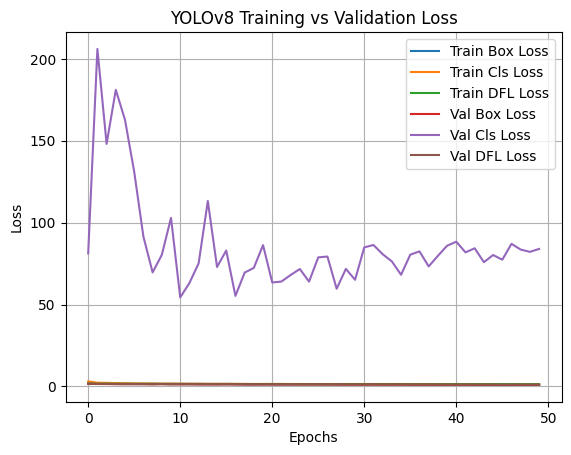

In [ ]:
import matplotlib.pyplot as plt

# extract columns
epochs = df.index

plt.figure()

# TRAINING LOSS
plt.plot(df['train/box_loss'], label='Train Box Loss')
plt.plot(df['train/cls_loss'], label='Train Cls Loss')
plt.plot(df['train/dfl_loss'], label='Train DFL Loss')

# VALIDATION LOSS
plt.plot(df['val/box_loss'], label='Val Box Loss')
plt.plot(df['val/cls_loss'], label='Val Cls Loss')
plt.plot(df['val/dfl_loss'], label='Val DFL Loss')

plt.title("YOLOv8 Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

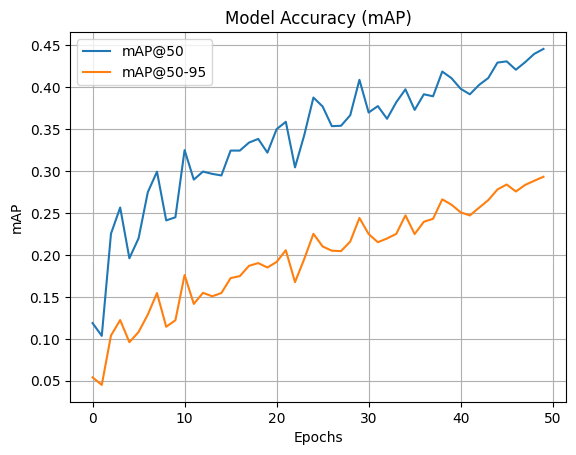

In [ ]:
plt.figure()

plt.plot(df['metrics/mAP50(B)'], label='mAP@50')
plt.plot(df['metrics/mAP50-95(B)'], label='mAP@50-95')

plt.title("Model Accuracy (mAP)")
plt.xlabel("Epochs")
plt.ylabel("mAP")
plt.legend()
plt.grid()
plt.show()

In [ ]:
metrics = model.val()

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.3 ms, read: 7.5±4.1 MB/s, size: 12.7 KB)
val: Scanning /content/drive/MyDrive/NEW/new/NEU-DET/val/labels/crazing.cache... 254 images, 360 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 614/614 257.5Mit/s 0.0s
val: /content/drive/MyDrive/NEW/new/NEU-DET/val/images/patches_198.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 4.7it/s 8.3s
                   all        614        642      0.398      0.697      0.444      0.292
               crazing         46        100      0.362      0.131      0.246       0.13
             inclusion         68        205      0.553      0.863      0.634      0.407
               patches         44        120      0.388      0.975      0.473      0.356
        pitte

In [ ]:
print("=== FINAL RESULTS ===")

print("mAP@0.5:", metrics.box.map50)
print("mAP@0.5:0.95:", metrics.box.map)

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

=== FINAL RESULTS ===
mAP@0.5: 0.44446195728132315
mAP@0.5:0.95: 0.29248345146214094
Precision: 0.39801591137818826
Recall: 0.6972830807167368
